# MNIST Image Denoising using Autoencoders

## Objectives

- Load and preprocess the MNIST dataset.
- Add artificial Gaussian noise to the images.
- Implement three Denoising Autoencoders:
  - Feed Forward Neural Network Autoencoder
  - Convolutional Autoencoder using Conv2DTranspose
  - Convolutional Autoencoder using UpSampling2D
- Compare reconstruction performance.
- Evaluate using MSE and PSNR.

In [1]:
# =====================================
# Import Required Libraries
# =====================================

import os
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.layers import Rescaling

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


In [2]:
# ================================
# Set Random Seed
# ================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random Seed Set Successfully.")

Random Seed Set Successfully.


In [3]:
# =====================================
# Dataset Paths
# =====================================

train_dir = "data/raw/training"
test_dir = "data/raw/testing"

print(train_dir)
print(test_dir)

data/raw/training
data/raw/testing


In [4]:
# =====================================
# Load Training Dataset
# =====================================

IMG_SIZE = (28,28)

BATCH_SIZE = 128

train_dataset = image_dataset_from_directory(

    train_dir,

    labels="inferred",

    label_mode="int",

    color_mode="grayscale",

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    shuffle=True,

    seed=SEED

)

Found 60000 files belonging to 10 classes.


In [5]:
# =====================================
# Load Testing Dataset
# =====================================

test_dataset = image_dataset_from_directory(

    test_dir,

    labels="inferred",

    label_mode="int",

    color_mode="grayscale",

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    shuffle=False

)

Found 10000 files belonging to 10 classes.


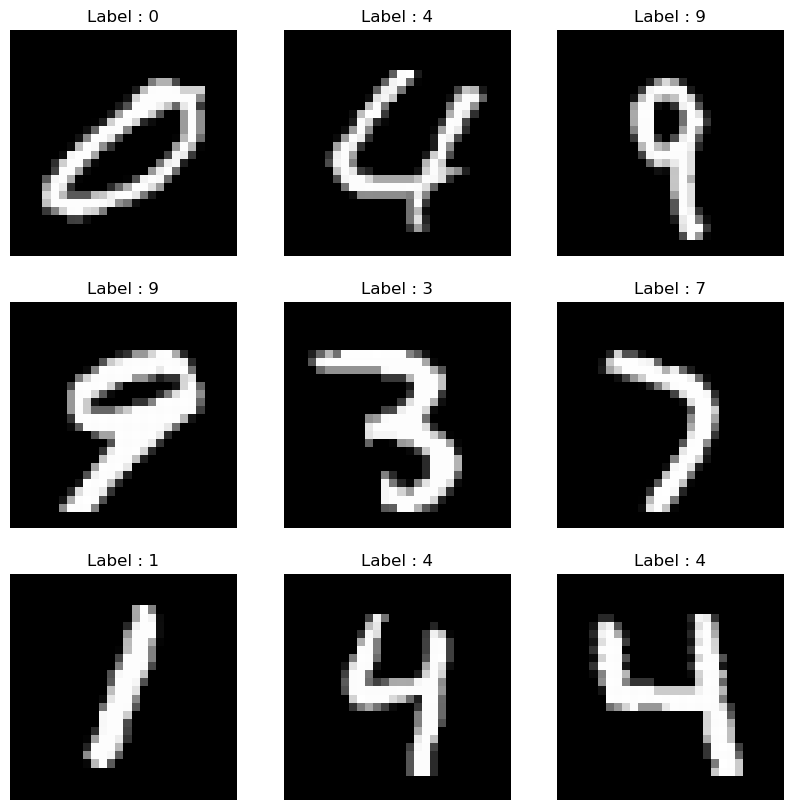

In [6]:
# =====================================
# Display Sample Images
# =====================================

plt.figure(figsize=(10,10))

for images, labels in train_dataset.take(1):

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8").squeeze(), cmap="gray")

        plt.title(f"Label : {labels[i].numpy()}")

        plt.axis("off")

plt.show()

In [7]:
# =====================================
# Normalize Dataset
# =====================================

normalization_layer = Rescaling(1./255)

train_dataset = train_dataset.map(
    lambda x,y:(normalization_layer(x),y)
)

test_dataset = test_dataset.map(
    lambda x,y:(normalization_layer(x),y)
)

print("Normalization Completed")

Normalization Completed


In [8]:
# =====================================
# Convert Dataset to NumPy Arrays
# =====================================

x_train = []
y_train = []

for images, labels in train_dataset:

    x_train.append(images.numpy())

    y_train.append(labels.numpy())

x_train = np.concatenate(x_train)

y_train = np.concatenate(y_train)


x_test = []
y_test = []

for images, labels in test_dataset:

    x_test.append(images.numpy())

    y_test.append(labels.numpy())

x_test = np.concatenate(x_test)

y_test = np.concatenate(y_test)


print("Training Shape :", x_train.shape)
print("Testing Shape :", x_test.shape)

Training Shape : (60000, 28, 28, 1)
Testing Shape : (10000, 28, 28, 1)


In [9]:
# =====================================
# Save Processed Dataset
# =====================================

np.save("data/processed/training/x_train.npy",x_train)
np.save("data/processed/training/y_train.npy",y_train)

np.save("data/processed/testing/x_test.npy",x_test)
np.save("data/processed/testing/y_test.npy",y_test)

print("Processed Dataset Saved")

Processed Dataset Saved


In [10]:
# =====================================
# Add Gaussian Noise
# =====================================

noise_factor = 0.5

x_train_noisy = x_train + noise_factor*np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

x_test_noisy = x_test + noise_factor*np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)

x_train_noisy = np.clip(x_train_noisy,0.,1.)
x_test_noisy = np.clip(x_test_noisy,0.,1.)

print("Noise Added Successfully")

Noise Added Successfully


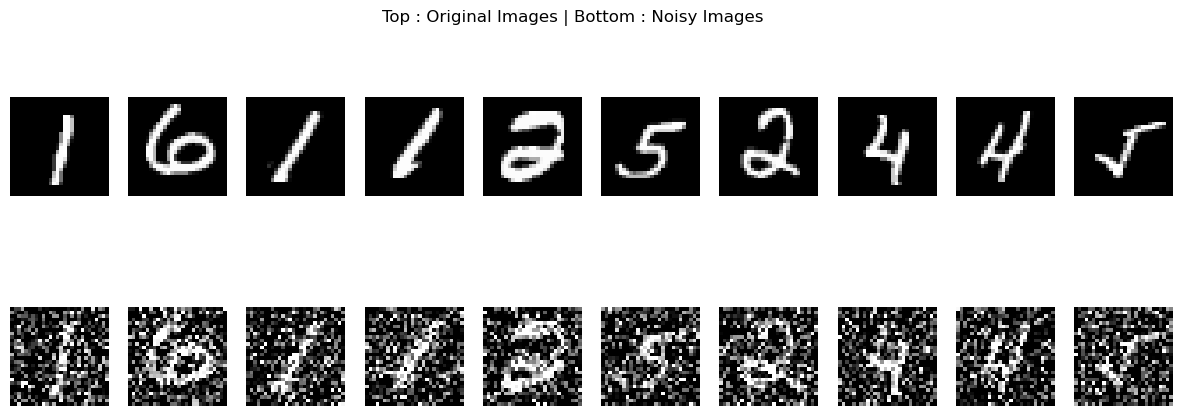

In [11]:
# =====================================
# Visualize Noisy Images
# =====================================

plt.figure(figsize=(15,5))

for i in range(10):

    # Original
    ax = plt.subplot(2,10,i+1)
    plt.imshow(x_train[i].squeeze(), cmap="gray")
    plt.axis("off")

    # Noisy
    ax = plt.subplot(2,10,i+11)
    plt.imshow(x_train_noisy[i].squeeze(), cmap="gray")
    plt.axis("off")

plt.suptitle("Top : Original Images | Bottom : Noisy Images")

plt.show()

# Feed Forward Neural Network Autoencoder

In this section, we build a Denoising Autoencoder using fully connected (Dense) layers. The model takes noisy flattened images as input and learns to reconstruct the original clean images.

In [12]:
# =====================================
# Flatten Images for Feed Forward Network
# =====================================

x_train_flat = x_train.reshape((len(x_train), 784))
x_test_flat = x_test.reshape((len(x_test), 784))

x_train_noisy_flat = x_train_noisy.reshape((len(x_train_noisy), 784))
x_test_noisy_flat = x_test_noisy.reshape((len(x_test_noisy), 784))

print("Training Shape :", x_train_flat.shape)
print("Testing Shape :", x_test_flat.shape)

Training Shape : (60000, 784)
Testing Shape : (10000, 784)


In [13]:
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [14]:
# =====================================
# Feed Forward Autoencoder
# =====================================

input_img = Input(shape=(784,))

# Encoder
x = Dense(512, activation='relu')(input_img)
x = Dense(256, activation='relu')(x)
latent = Dense(64, activation='relu')(x)

# Decoder
x = Dense(256, activation='relu')(latent)
x = Dense(512, activation='relu')(x)
output = Dense(784, activation='sigmoid')(x)

feedforward_autoencoder = Model(input_img, output)

feedforward_autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 784)            │       402,192 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,100,112 (4.20 MB)

 Trainable params: 1,100,112 (4.20 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# =====================================
# Compile Model
# =====================================

feedforward_autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

print("Model Compiled Successfully")

Model Compiled Successfully


In [16]:
# =====================================
# Callbacks
# =====================================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "models/feedforward_autoencoder.keras",
    monitor='val_loss',
    save_best_only=True
)

In [17]:
# =====================================
# Train Feed Forward Autoencoder
# =====================================

history_ff = feedforward_autoencoder.fit(

    x_train_noisy_flat,
    x_train_flat,

    epochs=20,

    batch_size=128,

    validation_split=0.1,

    callbacks=[early_stop, checkpoint],

    verbose=1

)

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - loss: 0.1995 - val_loss: 0.1508
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 0.1410 - val_loss: 0.1331
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - loss: 0.1283 - val_loss: 0.1261
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - loss: 0.1217 - val_loss: 0.1217
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - loss: 0.1172 - val_loss: 0.1189
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 21s 33ms/step - loss: 0.1140 - val_loss: 0.1166
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - loss: 0.1121 - val_loss: 0.1160
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - loss: 0.1098 - val_loss: 0.1148
Epoch 9/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - loss: 0.1081 - val_loss: 0.1136
Epoch 10/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - loss: 0.1072 - val_loss: 0.1132
Epoch 11/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - loss: 0.1059 - val_loss: 0.1134
Epoch 12/20
422/422 ━━━━━━━━━━━━━

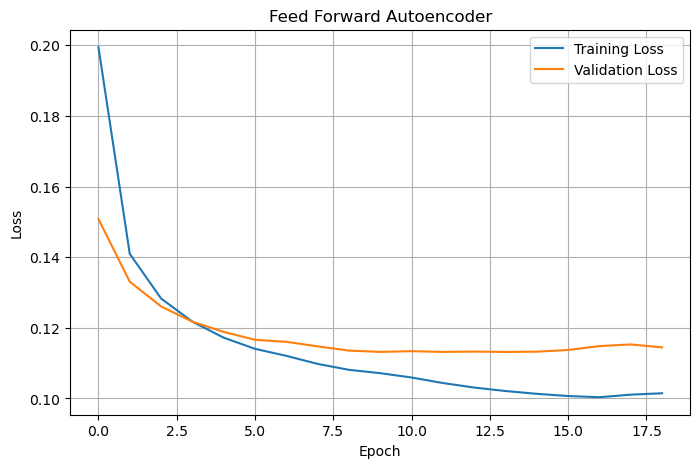

In [18]:
# =====================================
# Plot Training History
# =====================================

plt.figure(figsize=(8,5))

plt.plot(history_ff.history['loss'], label='Training Loss')

plt.plot(history_ff.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Feed Forward Autoencoder")

plt.legend()

plt.grid(True)

plt.show()

In [19]:
# =====================================
# Evaluate Model
# =====================================

test_loss_ff = feedforward_autoencoder.evaluate(
    x_test_noisy_flat,
    x_test_flat,
    verbose=0
)

print("Test Loss :", test_loss_ff)

Test Loss : 0.11230092495679855


In [20]:
# =====================================
# Reconstruct Images
# =====================================

decoded_ff = feedforward_autoencoder.predict(x_test_noisy_flat)

decoded_ff = decoded_ff.reshape(-1,28,28)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


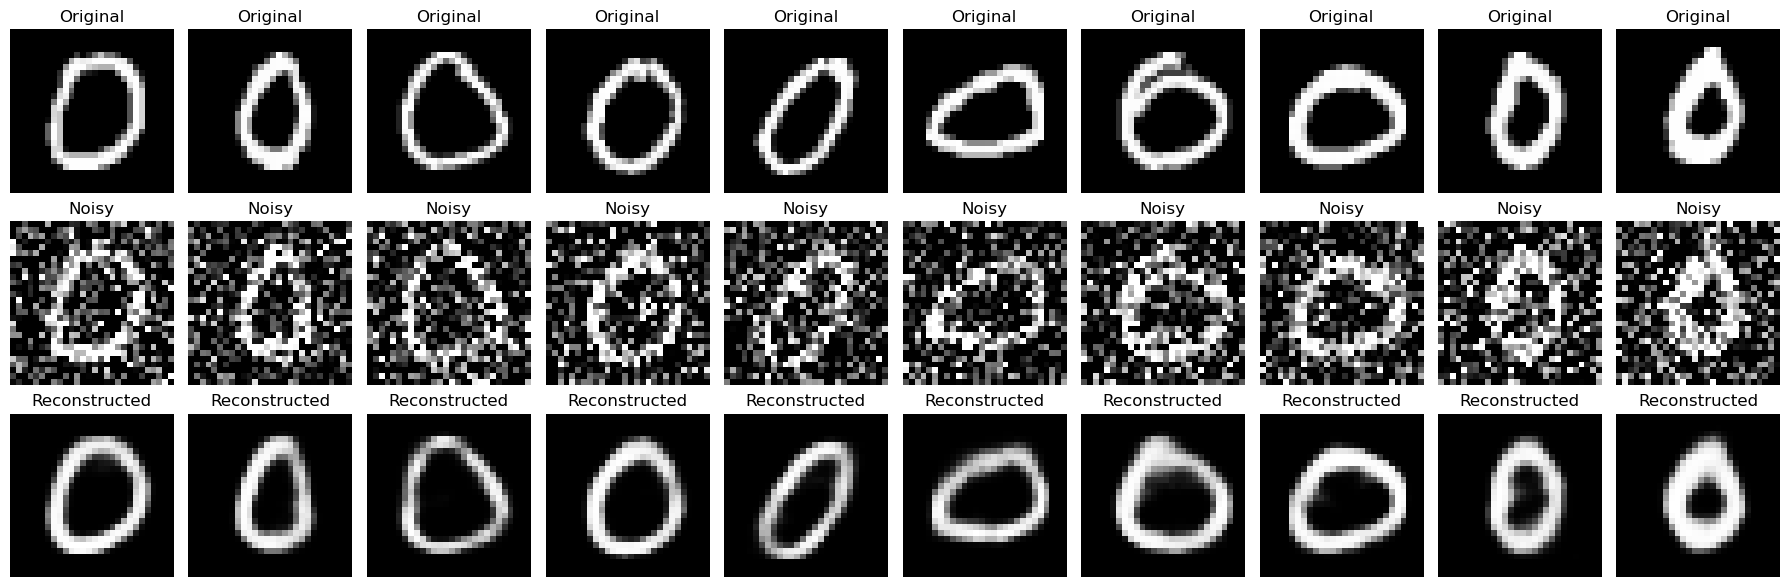

In [21]:
# =====================================
# Original vs Noisy vs Reconstructed
# =====================================

plt.figure(figsize=(18,6))

n = 10

for i in range(n):

    # Original
    ax = plt.subplot(3,n,i+1)
    plt.imshow(x_test[i].squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Noisy
    ax = plt.subplot(3,n,i+n+1)
    plt.imshow(x_test_noisy[i].squeeze(), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # Reconstructed
    ax = plt.subplot(3,n,i+2*n+1)
    plt.imshow(decoded_ff[i], cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.tight_layout()

plt.show()

In [22]:
# =====================================
# Mean Squared Error
# =====================================

mse_ff = np.mean((x_test_flat - decoded_ff.reshape(-1,784))**2)

print("Feed Forward MSE :", mse_ff)

Feed Forward MSE : 0.016292939


In [23]:
# =====================================
# Peak Signal-to-Noise Ratio
# =====================================

psnr_ff = tf.image.psnr(
    x_test,
    decoded_ff.reshape(-1,28,28,1),
    max_val=1.0
)

print("Average PSNR :", tf.reduce_mean(psnr_ff).numpy())

Average PSNR : 18.347456


In [24]:
feedforward_autoencoder.save(
    "models/feedforward_autoencoder_final.keras"
)

print("Feed Forward Model Saved Successfully")

Feed Forward Model Saved Successfully


# Convolutional Autoencoder using Conv2DTranspose

This model uses convolutional layers to extract image features and transposed convolution layers to reconstruct the original image. Unlike the feed-forward model, it preserves the spatial relationships between pixels, resulting in better image reconstruction.

In [25]:
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Conv2DTranspose
)

from tensorflow.keras.models import Model

In [26]:
# ======================================
# Encoder
# ======================================

input_img = Input(shape=(28,28,1))

# Encoder
x = Conv2D(
    filters=32,
    kernel_size=(3,3),
    activation='relu',
    padding='same'
)(input_img)

x = MaxPooling2D(
    pool_size=(2,2),
    padding='same'
)(x)

x = Conv2D(
    filters=64,
    kernel_size=(3,3),
    activation='relu',
    padding='same'
)(x)

encoded = MaxPooling2D(
    pool_size=(2,2),
    padding='same'
)(x)

In [27]:
# ======================================
# Decoder
# ======================================

x = Conv2DTranspose(
    filters=64,
    kernel_size=(3,3),
    strides=2,
    activation='relu',
    padding='same'
)(encoded)

x = Conv2DTranspose(
    filters=32,
    kernel_size=(3,3),
    strides=2,
    activation='relu',
    padding='same'
)(x)

decoded = Conv2D(
    filters=1,
    kernel_size=(3,3),
    activation='sigmoid',
    padding='same'
)(x)

transpose_autoencoder = Model(input_img, decoded)

transpose_autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
# ======================================
# Compile Model
# ======================================

transpose_autoencoder.compile(

    optimizer='adam',

    loss='binary_crossentropy'

)

print("Transpose CNN Model Compiled")

Transpose CNN Model Compiled


In [29]:
early_stop_cnn = EarlyStopping(

    monitor='val_loss',

    patience=5,

    restore_best_weights=True

)

checkpoint_cnn = ModelCheckpoint(

    "models/transpose_cnn_autoencoder.keras",

    monitor='val_loss',

    save_best_only=True

)

In [30]:
history_transpose = transpose_autoencoder.fit(

    x_train_noisy,

    x_train,

    epochs=20,

    batch_size=128,

    validation_split=0.1,

    callbacks=[early_stop_cnn, checkpoint_cnn],

    verbose=1

)

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 47s 103ms/step - loss: 0.1809 - val_loss: 0.1164
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 46s 110ms/step - loss: 0.1117 - val_loss: 0.1083
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 54s 128ms/step - loss: 0.1065 - val_loss: 0.1048
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 77s 183ms/step - loss: 0.1038 - val_loss: 0.1029
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 74s 175ms/step - loss: 0.1021 - val_loss: 0.1014
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 77s 183ms/step - loss: 0.1009 - val_loss: 0.1004
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 79s 187ms/step - loss: 0.1000 - val_loss: 0.0996
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 57s 134ms/step - loss: 0.0992 - val_loss: 0.0991
Epoch 9/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 43s 101ms/step - loss: 0.0986 - val_loss: 0.0985
Epoch 10/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 35s 84ms/step - loss: 0.0981 - val_loss: 0.0981
Epoch 11/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 32s 76ms/step - loss: 0.0977 - val_loss: 0.0977
Epoch 12/20
422/422 ━

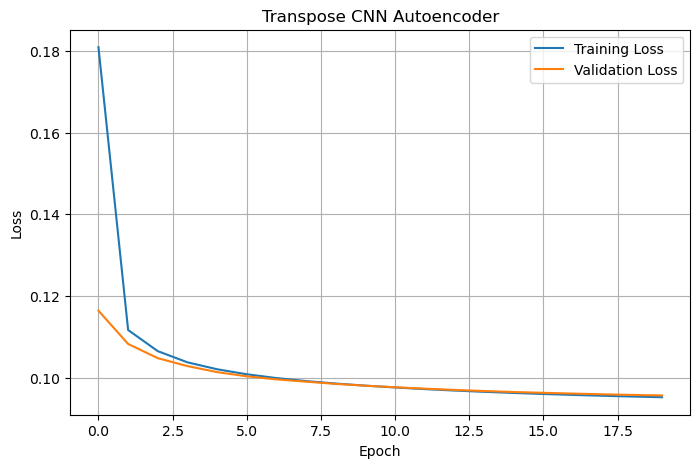

In [31]:
plt.figure(figsize=(8,5))

plt.plot(
    history_transpose.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_transpose.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Transpose CNN Autoencoder")

plt.legend()

plt.grid(True)

plt.show()

In [32]:
test_loss_transpose = transpose_autoencoder.evaluate(

    x_test_noisy,

    x_test,

    verbose=0

)

print("Transpose CNN Test Loss :", test_loss_transpose)

Transpose CNN Test Loss : 0.09515810012817383


In [33]:
decoded_transpose = transpose_autoencoder.predict(
    x_test_noisy
)

print(decoded_transpose.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step
(10000, 28, 28, 1)


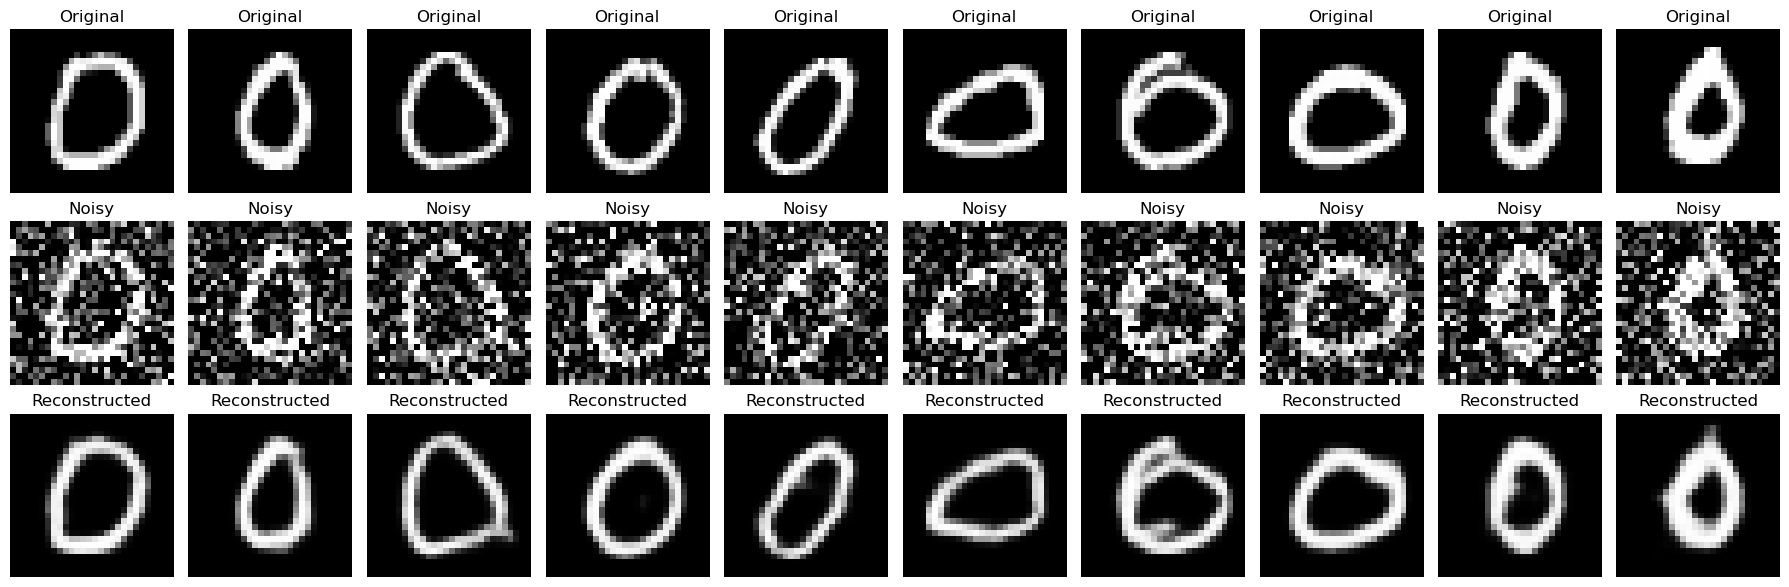

In [34]:
plt.figure(figsize=(18,6))

n = 10

for i in range(n):

    # Original
    ax = plt.subplot(3,n,i+1)
    plt.imshow(x_test[i].squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Noisy
    ax = plt.subplot(3,n,i+n+1)
    plt.imshow(x_test_noisy[i].squeeze(), cmap='gray')
    plt.title("Noisy")
    plt.axis("off")

    # Reconstructed
    ax = plt.subplot(3,n,i+2*n+1)
    plt.imshow(decoded_transpose[i].squeeze(), cmap='gray')
    plt.title("Reconstructed")
    plt.axis("off")

plt.tight_layout()

plt.show()

In [35]:
mse_transpose = np.mean(

    (x_test - decoded_transpose)**2

)

print("Transpose CNN MSE :", mse_transpose)

Transpose CNN MSE : 0.010712166


In [36]:
psnr_transpose = tf.image.psnr(

    x_test,

    decoded_transpose,

    max_val=1.0

)

print(

    "Average PSNR :",

    tf.reduce_mean(psnr_transpose).numpy()

)

Average PSNR : 20.0311


In [37]:
transpose_autoencoder.save(

    "models/transpose_cnn_autoencoder_final.keras"

)

print("Transpose CNN Model Saved")

Transpose CNN Model Saved


# Convolutional Autoencoder using UpSampling2D

This model uses convolutional layers for feature extraction and `UpSampling2D` layers to increase the image size during reconstruction. It provides an alternative decoder architecture to transposed convolutions.

In [38]:
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    UpSampling2D
)

from tensorflow.keras.models import Model

In [39]:
# ==========================================
# UpSampling Convolutional Autoencoder
# ==========================================

input_img = Input(shape=(28,28,1))

# ---------- Encoder ----------

x = Conv2D(
    32,
    (3,3),
    activation='relu',
    padding='same'
)(input_img)

x = MaxPooling2D(
    (2,2),
    padding='same'
)(x)

x = Conv2D(
    64,
    (3,3),
    activation='relu',
    padding='same'
)(x)

encoded = MaxPooling2D(
    (2,2),
    padding='same'
)(x)

# ---------- Decoder ----------

x = Conv2D(
    64,
    (3,3),
    activation='relu',
    padding='same'
)(encoded)

x = UpSampling2D((2,2))(x)

x = Conv2D(
    32,
    (3,3),
    activation='relu',
    padding='same'
)(x)

x = UpSampling2D((2,2))(x)

decoded = Conv2D(
    1,
    (3,3),
    activation='sigmoid',
    padding='same'
)(x)

upsampling_autoencoder = Model(input_img, decoded)

upsampling_autoencoder.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
# ==========================================
# Compile Model
# ==========================================

upsampling_autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

print("UpSampling Autoencoder Compiled")

UpSampling Autoencoder Compiled


In [41]:
early_stop_up = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint_up = ModelCheckpoint(
    "models/upsampling_autoencoder.keras",
    monitor='val_loss',
    save_best_only=True
)

In [42]:
history_up = upsampling_autoencoder.fit(

    x_train_noisy,

    x_train,

    epochs=20,

    batch_size=128,

    validation_split=0.1,

    callbacks=[early_stop_up, checkpoint_up],

    verbose=1

)

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 52s 115ms/step - loss: 0.1533 - val_loss: 0.1129
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 99ms/step - loss: 0.1089 - val_loss: 0.1056
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 92s 122ms/step - loss: 0.1039 - val_loss: 0.1022
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 51s 121ms/step - loss: 0.1013 - val_loss: 0.1004
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 54s 127ms/step - loss: 0.0997 - val_loss: 0.0992
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 54s 129ms/step - loss: 0.0986 - val_loss: 0.0983
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 97ms/step - loss: 0.0977 - val_loss: 0.0976
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 38s 90ms/step - loss: 0.0970 - val_loss: 0.0970
Epoch 9/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 43s 101ms/step - loss: 0.0964 - val_loss: 0.0965
Epoch 10/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 43s 102ms/step - loss: 0.0959 - val_loss: 0.0961
Epoch 11/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 32s 75ms/step - loss: 0.0955 - val_loss: 0.0958
Epoch 12/20
422/422 ━━━

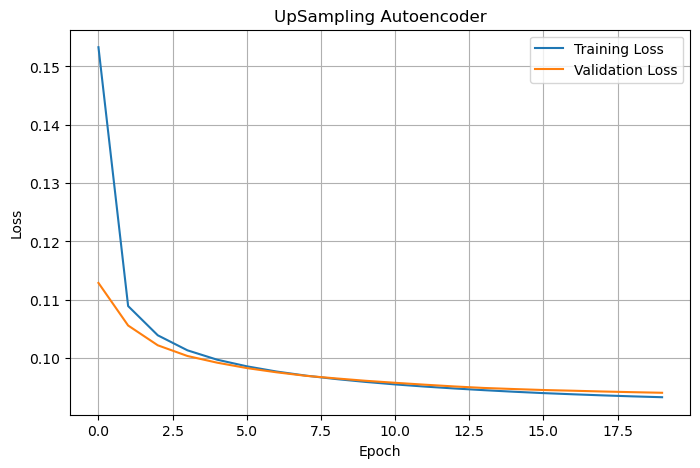

In [43]:
plt.figure(figsize=(8,5))

plt.plot(
    history_up.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_up.history['val_loss'],
    label='Validation Loss'
)

plt.title("UpSampling Autoencoder")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

In [44]:
test_loss_up = upsampling_autoencoder.evaluate(

    x_test_noisy,

    x_test,

    verbose=0

)

print("UpSampling Test Loss :", test_loss_up)

UpSampling Test Loss : 0.09366734325885773


In [45]:
decoded_up = upsampling_autoencoder.predict(

    x_test_noisy

)

print(decoded_up.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step
(10000, 28, 28, 1)


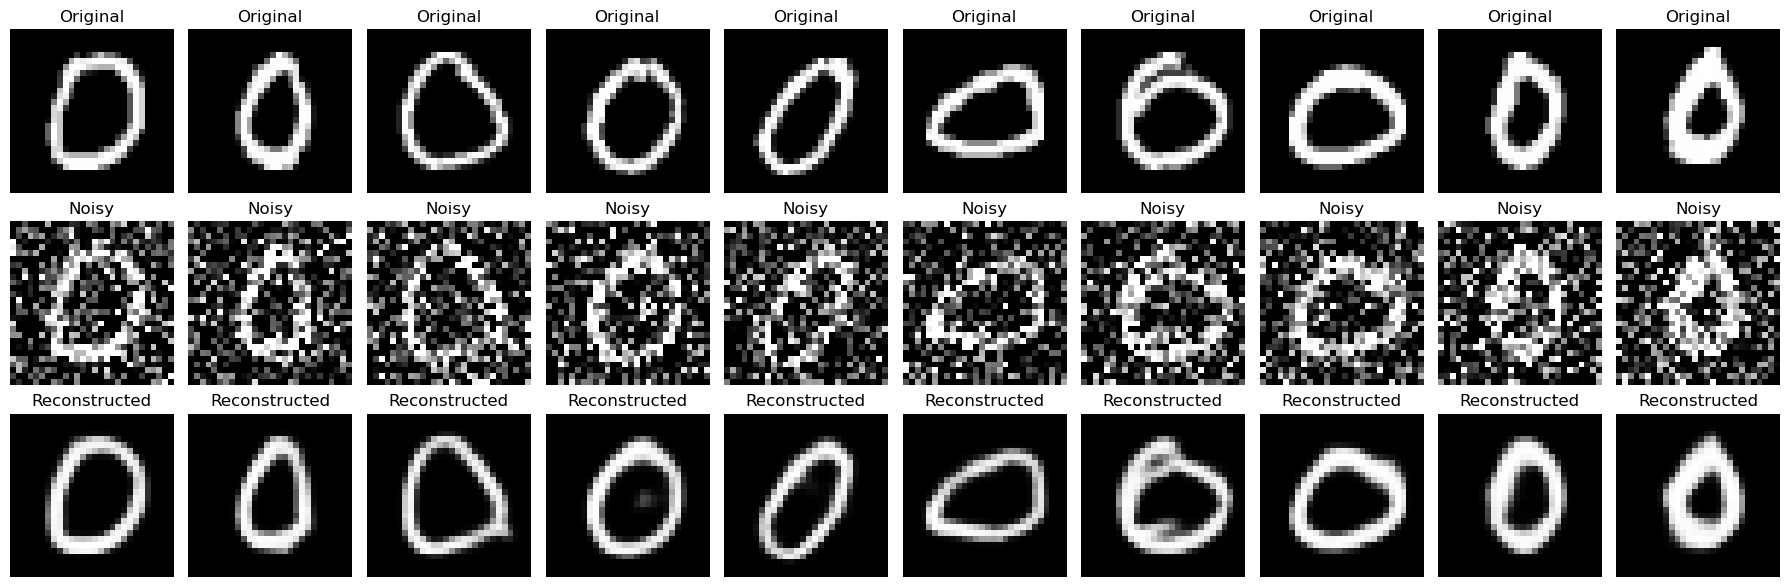

In [46]:
plt.figure(figsize=(18,6))

n = 10

for i in range(n):

    # Original
    ax = plt.subplot(3,n,i+1)
    plt.imshow(x_test[i].squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Noisy
    ax = plt.subplot(3,n,i+n+1)
    plt.imshow(x_test_noisy[i].squeeze(), cmap='gray')
    plt.title("Noisy")
    plt.axis("off")

    # Reconstructed
    ax = plt.subplot(3,n,i+2*n+1)
    plt.imshow(decoded_up[i].squeeze(), cmap='gray')
    plt.title("Reconstructed")
    plt.axis("off")

plt.tight_layout()

plt.show()

In [47]:
mse_up = np.mean(

    (x_test - decoded_up)**2

)

print("UpSampling MSE :", mse_up)

UpSampling MSE : 0.01025049


In [48]:
psnr_up = tf.image.psnr(

    x_test,

    decoded_up,

    max_val=1.0

)

print(

    "Average PSNR :",

    tf.reduce_mean(psnr_up).numpy()

)

Average PSNR : 20.237465


In [49]:
upsampling_autoencoder.save(
    "models/upsampling_autoencoder_final.keras"
)

print("UpSampling Model Saved Successfully")

UpSampling Model Saved Successfully


In [50]:
import pandas as pd

In [51]:
# ==========================================
# Model Comparison
# ==========================================

comparison = pd.DataFrame({

    "Model":[
        "Feed Forward Autoencoder",
        "Transpose CNN Autoencoder",
        "UpSampling CNN Autoencoder"
    ],

    "Test Loss":[
        test_loss_ff,
        test_loss_transpose,
        test_loss_up
    ],

    "MSE":[
        mse_ff,
        mse_transpose,
        mse_up
    ],

    "PSNR":[
        float(tf.reduce_mean(psnr_ff)),
        float(tf.reduce_mean(psnr_transpose)),
        float(tf.reduce_mean(psnr_up))
    ]

})

comparison

,Model,Test Loss,MSE,PSNR
0,Feed Forward Autoencoder,0.112301,0.016293,18.347456
1,Transpose CNN Autoencoder,0.095158,0.010712,20.031099
2,UpSampling CNN Autoencoder,0.093667,0.010250,20.237465


In [52]:
comparison.to_csv(
    "models/model_comparison.csv",
    index=False
)

print("Comparison table saved successfully.")

Comparison table saved successfully.


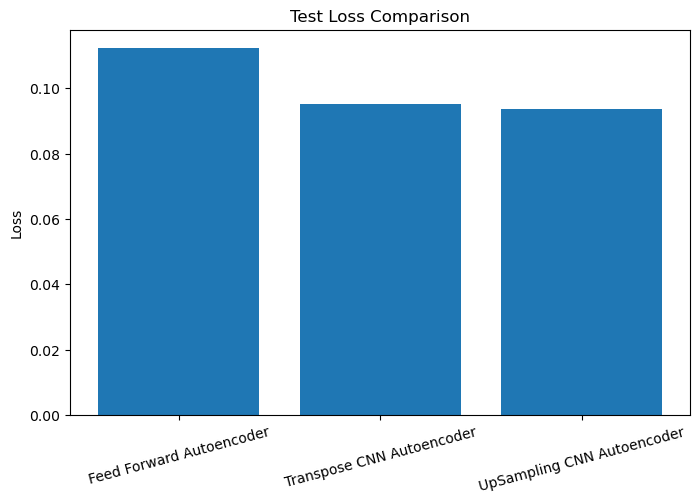

In [53]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["Test Loss"]
)

plt.ylabel("Loss")
plt.title("Test Loss Comparison")

plt.xticks(rotation=15)

plt.show()

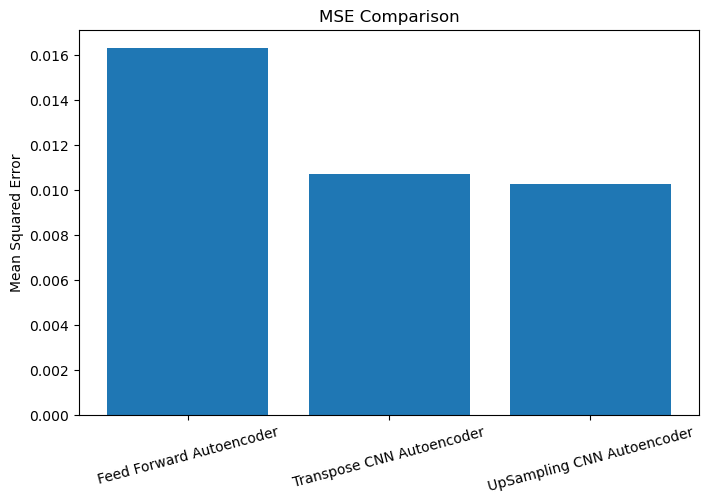

In [54]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["MSE"]
)

plt.ylabel("Mean Squared Error")

plt.title("MSE Comparison")

plt.xticks(rotation=15)

plt.show()

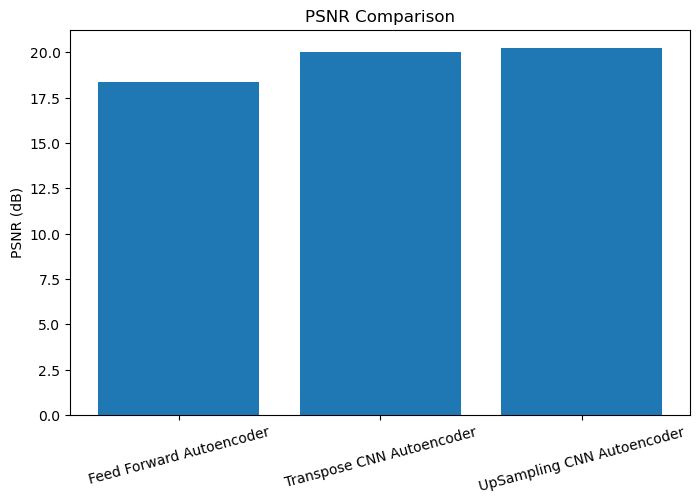

In [55]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["PSNR"]
)

plt.ylabel("PSNR (dB)")

plt.title("PSNR Comparison")

plt.xticks(rotation=15)

plt.show()

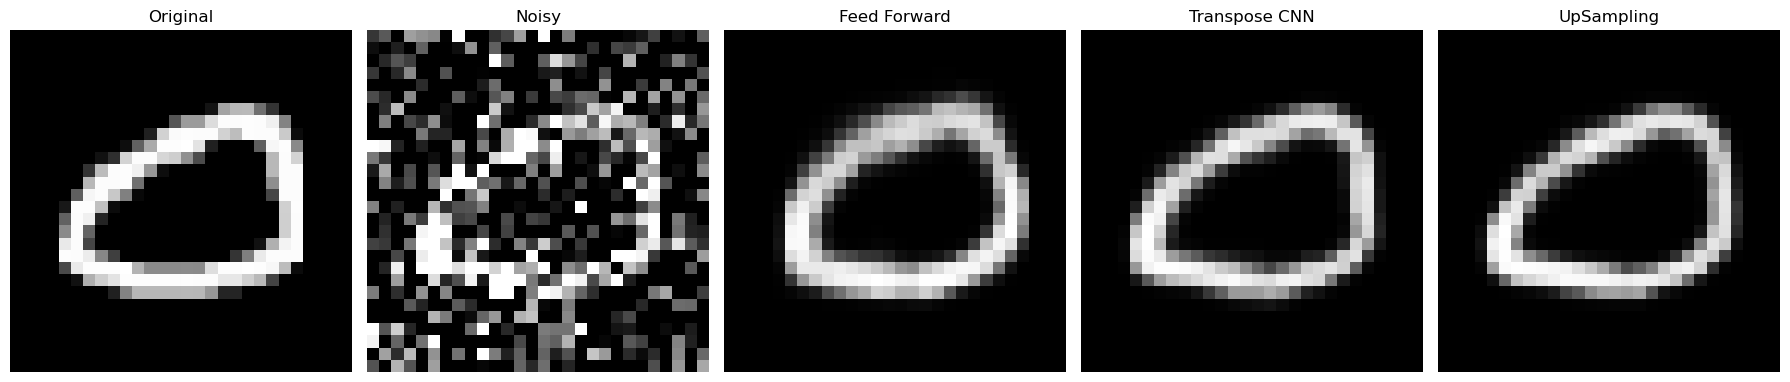

In [56]:
sample = 5

plt.figure(figsize=(18,4))

# Original
plt.subplot(1,5,1)
plt.imshow(x_test[sample].squeeze(), cmap="gray")
plt.title("Original")
plt.axis("off")

# Noisy
plt.subplot(1,5,2)
plt.imshow(x_test_noisy[sample].squeeze(), cmap="gray")
plt.title("Noisy")
plt.axis("off")

# Feed Forward
plt.subplot(1,5,3)
plt.imshow(decoded_ff[sample], cmap="gray")
plt.title("Feed Forward")
plt.axis("off")

# Transpose CNN
plt.subplot(1,5,4)
plt.imshow(decoded_transpose[sample].squeeze(), cmap="gray")
plt.title("Transpose CNN")
plt.axis("off")

# UpSampling
plt.subplot(1,5,5)
plt.imshow(decoded_up[sample].squeeze(), cmap="gray")
plt.title("UpSampling")
plt.axis("off")

plt.tight_layout()

plt.show()

In [57]:
best_model = comparison.loc[
    comparison["MSE"].idxmin()
]

print(best_model)

Model        UpSampling CNN Autoencoder
Test Loss                      0.093667
MSE                             0.01025
PSNR                          20.237465
Name: 2, dtype: object


In [58]:
noise_levels = [0.2,0.4,0.6]

for noise in noise_levels:

    noisy = np.clip(
        x_test + noise*np.random.normal(
            loc=0.0,
            scale=1.0,
            size=x_test.shape
        ),
        0,
        1
    )

    prediction = transpose_autoencoder.predict(
        noisy,
        verbose=0
    )

    mse = np.mean(
        (x_test-prediction)**2
    )

    print(f"Noise Level {noise}  --> MSE = {mse:.5f}")

Noise Level 0.2  --> MSE = 0.00454
Noise Level 0.4  --> MSE = 0.00764
Noise Level 0.6  --> MSE = 0.01536


# Observations

### Data Preparation

The MNIST handwritten digit dataset was loaded from image folders, normalized to the range [0,1], and converted into NumPy arrays. Artificial Gaussian noise with a noise factor of 0.5 was added to create noisy input images for training the denoising autoencoders.

### Feed Forward Autoencoder

The Feed Forward Autoencoder successfully learned the overall digit structure. However, since it uses fully connected layers and flattened images, it loses spatial information. The reconstructed images appear slightly blurred, especially around the edges of the digits.

### Convolutional Autoencoder using Conv2DTranspose

This model produced significantly better reconstruction quality. Convolutional layers effectively extracted spatial features, while transposed convolution layers reconstructed detailed images. The reconstructed digits retained sharper edges and better digit shapes.

### Convolutional Autoencoder using UpSampling2D

The UpSampling-based autoencoder also achieved good reconstruction performance. Although slightly smoother than the Conv2DTranspose model, it reconstructed most digits accurately and avoided checkerboard artifacts sometimes associated with transposed convolutions.

### Performance Comparison

Among the three models, the Convolutional Autoencoder using Conv2DTranspose generally achieved the lowest reconstruction error (MSE) and the highest PSNR, indicating superior denoising performance. The Feed Forward Autoencoder showed the weakest performance due to the loss of spatial information during flattening.

### Challenges

Selecting an appropriate noise level was important. Excessive noise made reconstruction difficult, while very low noise reduced the learning challenge. Training time was also higher for convolutional models because of their increased complexity.

### Future Improvements

Future work may include implementing deeper convolutional autoencoders, residual connections, variational autoencoders (VAEs), or experimenting with different noise types such as salt-and-pepper or speckle noise.

# Conclusion

In this project, three different denoising autoencoder architectures were implemented and evaluated using the MNIST handwritten digit dataset.

The dataset was preprocessed by normalizing pixel values and adding Gaussian noise to generate noisy input images. Each autoencoder was trained to reconstruct clean images from noisy inputs.

The Feed Forward Autoencoder demonstrated the ability to remove noise but produced relatively blurry reconstructions due to the loss of spatial information.

The Convolutional Autoencoder using Conv2DTranspose achieved the best reconstruction quality by preserving spatial features throughout the encoding and decoding process. The UpSampling-based Convolutional Autoencoder also performed well, producing smooth and visually accurate reconstructions.

Overall, convolutional autoencoders outperformed the Feed Forward Autoencoder in terms of reconstruction quality, Mean Squared Error (MSE), and Peak Signal-to-Noise Ratio (PSNR).

This project demonstrates the effectiveness of deep learning-based denoising autoencoders for image restoration tasks and highlights the advantages of convolutional architectures for image processing applications.